In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import os
import zipfile

zip_path   = "/content/drive/MyDrive/ШІ в лінгвістиці лаб 1/ЗШІвЛ.zip"
extract_path= "/content/drive/MyDrive/ШІ в лінгвістиці лаб 1/ЗШІвЛ1"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Розпаковано в:", extract_path)
print(os.listdir(extract_path)[:20])

Розпаковано в: /content/drive/MyDrive/ШІ в лінгвістиці лаб 1/ЗШІвЛ1
['dataset', 'American@84Vn2Z.png']


In [4]:

print("Symbol exists:", os.path.exists(extract_path))
print("Symbol content:", os.listdir(extract_path)[:20] if os.path.exists(extract_path) else "not found")

SMALL exists: True
SMALL content: ['dataset']


In [7]:
for root, dirs, files in os.walk(extract_path):
    print("FOLDER:", root)
    print("  subfolders:", dirs[:10])
    print("  files:", files[:10])
    print()
    if root.count(os.sep) > extract_path.count(os.sep) + 2:
        break

FOLDER: /content/drive/MyDrive/ШІ в лінгвістиці лаб 1/ЗШІвЛ1
  subfolders: ['dataset']
  files: ['American@84Vn2Z.png']

FOLDER: /content/drive/MyDrive/ШІ в лінгвістиці лаб 1/ЗШІвЛ1/dataset
  subfolders: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
  files: ['.directory']

FOLDER: /content/drive/MyDrive/ШІ в лінгвістиці лаб 1/ЗШІвЛ1/dataset/0
  subfolders: []
  files: ['0CdBlhLw.png', '10014.jpg', '1058.jpg', '10679.jpg', '10825.jpg', '10892.jpg', '10941.jpg', '10970.jpg', '1199.jpg', '12488.jpg']

FOLDER: /content/drive/MyDrive/ШІ в лінгвістиці лаб 1/ЗШІвЛ1/dataset/1
  subfolders: []
  files: ['10107.jpg', '10395.jpg', '10843.jpg', '1100.jpg', '11036.jpg', '11075.jpg', '11429.jpg', '11449.jpg', '11513.jpg', '11589.jpg']

FOLDER: /content/drive/MyDrive/ШІ в лінгвістиці лаб 1/ЗШІвЛ1/dataset/2
  subfolders: []
  files: ['0Yyn3PUt.png', '10276.jpg', '10379.jpg', '10423.jpg', '11089.jpg', '11258.jpg', '11558.jpg', '11637.jpg', '12066.jpg', '12357.jpg']

FOLDER: /content/drive/MyDrive

In [11]:
from google.colab import drive
drive.mount('/content/drive')

import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

DATASET_DIR = "/content/drive/MyDrive/ШІ в лінгвістиці лаб 1/ЗШІвЛ1/dataset"

IMG_SIZE = (64, 128)
BATCH = 32
SEED = 42

full_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    image_size=IMG_SIZE,
    batch_size=None,
    shuffle=True,
    seed=SEED
)

class_names = full_ds.class_names
num_classes = len(class_names)

print("Класи:", class_names)
print("К-сть класів:", num_classes)

# нормалізація
full_ds = full_ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y))

dataset_size = tf.data.experimental.cardinality(full_ds).numpy()

# train / val / test split
n_train = int(0.7 * dataset_size)
n_val   = int(0.15 * dataset_size)
n_test  = dataset_size - n_train - n_val

train_ds = full_ds.take(n_train)
temp_ds  = full_ds.skip(n_train)
val_ds   = temp_ds.take(n_val)
test_ds  = temp_ds.skip(n_val)

train_ds = train_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

print("train:", n_train, "val:", n_val, "test:", n_test)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 10071 files belonging to 19 classes.
Класи: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'add', 'dec', 'div', 'eq', 'mul', 'sub', 'x', 'y', 'z']
К-сть класів: 19
train: 7049 val: 1510 test: 1512


In [13]:
# створення моделі
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(64, 128, 3)),

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 126, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 14, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,376,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 19)             │         2,451 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,472,083 (5.62 MB)

 Trainable params: 1,472,083 (5.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Навчання

In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8
)

Epoch 1/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 166s 744ms/step - accuracy: 0.5753 - loss: 1.4450 - val_accuracy: 0.8298 - val_loss: 0.6107
Epoch 2/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 162s 731ms/step - accuracy: 0.8546 - loss: 0.4719 - val_accuracy: 0.8967 - val_loss: 0.3266
Epoch 3/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 199s 716ms/step - accuracy: 0.9240 - loss: 0.2498 - val_accuracy: 0.9232 - val_loss: 0.2715
Epoch 4/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 157s 713ms/step - accuracy: 0.9498 - loss: 0.1568 - val_accuracy: 0.9411 - val_loss: 0.2385
Epoch 5/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 155s 700ms/step - accuracy: 0.9684 - loss: 0.0965 - val_accuracy: 0.9338 - val_loss: 0.2295
Epoch 6/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 154s 697ms/step - accuracy: 0.9745 - loss: 0.0824 - val_accuracy: 0.9497 - val_loss: 0.1880
Epoch 7/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 154s 697ms/step - accuracy: 0.9807 - loss: 0.0570 - val_accuracy: 0.9457 - val_loss: 0.2416
Epoch 8/8
221/221 ━━━━━━━━━━━━━━━━━━━━ 160s 722ms/step - accuracy: 0.9855 - loss: 0

In [15]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print("\ntest точність:", round(float(test_acc), 4))


test точність: 0.9134


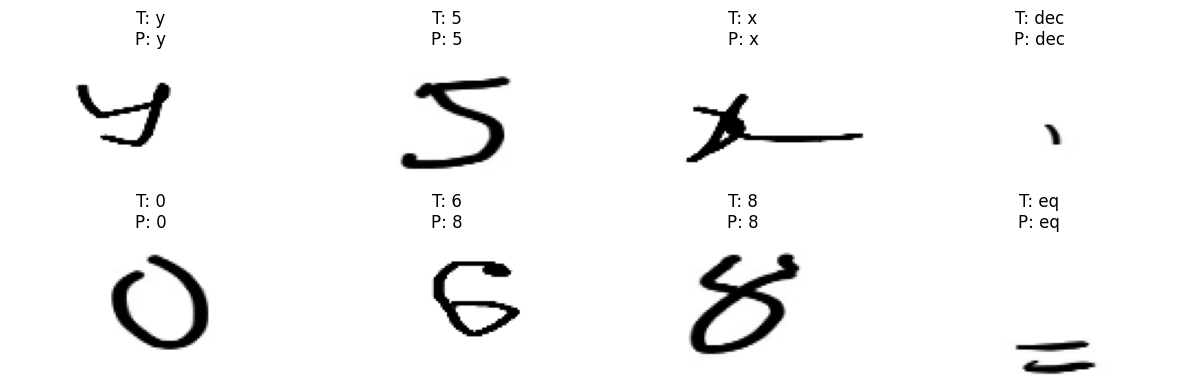

In [16]:
images, labels = next(iter(test_ds))
pred = model.predict(images, verbose=0)
pred_ids = np.argmax(pred, axis=1)

plt.figure(figsize=(12, 4))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].numpy())
    t = class_names[int(labels[i].numpy())]
    p = class_names[int(pred_ids[i])]
    plt.title(f"T: {t}\nP: {p}")
    plt.axis("off")

plt.tight_layout()
plt.show()

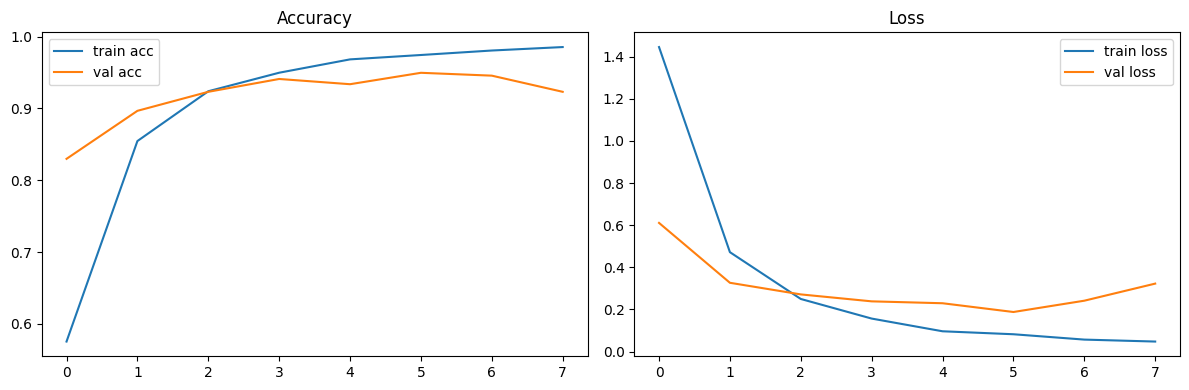

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

Тепер зробимо тест на виразі, напишемо в програмі Paint математичний вираз, завантажимо в google colab і протестуємо модель

In [19]:
import cv2

#мапа позначень
label_to_token = {
    "add": "add",
    "sub": "sub",
    "mul": "mul",
    "div": "div",
    "eq": "eq",
    "dec": "dec",
    "x": "x",
    "y": "y",
    "z": "z",
    "0": "0",
    "1": "1",
    "2": "2",
    "3": "3",
    "4": "4",
    "5": "5",
    "6": "6",
    "7": "7",
    "8": "8",
    "9": "9",
}

In [21]:
# Функція вирізання символів із картинки (Функція вирізання символів із картинки; світлий фон; темні символи)
def segment_symbols(image_path, min_area=50, show_steps=True):
    # читаємо картинку
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Не вдалося відкрити зображення: {image_path}")

    original = img.copy()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # бінаризація: темне -> біле, фон -> чорний
    _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

    # трохи чистимо шум
    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    # пошук контурів
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = w * h
        if area >= min_area:
            boxes.append((x, y, w, h))

    # сортування зліва направо
    boxes = sorted(boxes, key=lambda b: b[0])

    symbols = []
    vis = original.copy()

    for (x, y, w, h) in boxes:
        pad = 8
        x1 = max(0, x - pad)
        y1 = max(0, y - pad)
        x2 = min(thresh.shape[1], x + w + pad)
        y2 = min(thresh.shape[0], y + h + pad)

        crop = thresh[y1:y2, x1:x2]
        symbols.append(crop)

        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)

    if show_steps:
        plt.figure(figsize=(15, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        plt.title("Оригінал")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(thresh, cmap="gray")
        plt.title("Бінаризація")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title("Знайдені символи")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    return symbols, boxes

In [22]:
# Підготовка одного вирізаного символу під модель
def prepare_symbol_for_model(symbol_img, img_size=(64, 128)):
    # symbol_img тут уже чорно-білий, де символ білий на чорному
    h, w = symbol_img.shape

    # робимо квадратне/прямокутне полотно з відступами
    canvas = np.zeros((max(h, 20), max(w, 20)), dtype=np.uint8)

    y_offset = (canvas.shape[0] - h) // 2
    x_offset = (canvas.shape[1] - w) // 2
    canvas[y_offset:y_offset+h, x_offset:x_offset+w] = symbol_img

    # invert, щоб фон став білим, а символ темним — ближче до датасету
    canvas = 255 - canvas

    resized = cv2.resize(canvas, (img_size[1], img_size[0]))  # (width, height)
    rgb = cv2.cvtColor(resized, cv2.COLOR_GRAY2RGB)
    rgb = rgb.astype("float32") / 255.0

    return rgb

In [23]:
# Розпізнавання всього виразу
def predict_expression(image_path, model, class_names, img_size=(64, 128), min_area=50, show_symbols=True):
    symbols, boxes = segment_symbols(image_path, min_area=min_area, show_steps=True)

    if len(symbols) == 0:
        raise ValueError("Не знайдено жодного символу. Спробуй товстіше написати або збільшити контраст.")

    prepared = []
    predicted_labels = []
    confidences = []

    for sym in symbols:
        img = prepare_symbol_for_model(sym, img_size=img_size)
        prepared.append(img)

        pred = model.predict(np.expand_dims(img, axis=0), verbose=0)
        pred_id = int(np.argmax(pred, axis=1)[0])
        pred_label = class_names[pred_id]
        conf = float(np.max(pred))

        predicted_labels.append(pred_label)
        confidences.append(conf)

    tokens = [label_to_token.get(lbl, lbl) for lbl in predicted_labels]
    expression = "".join(tokens)

    if show_symbols:
        plt.figure(figsize=(3 * len(prepared), 3))
        for i, img in enumerate(prepared):
            plt.subplot(1, len(prepared), i + 1)
            plt.imshow(img)
            plt.title(f"{predicted_labels[i]}\n{confidences[i]:.2f}")
            plt.axis("off")
        plt.tight_layout()
        plt.show()

    return expression, predicted_labels, confidences, boxes

In [24]:
from google.colab import files
uploaded = files.upload()

Saving ВиразТест1.png to ВиразТест1.png


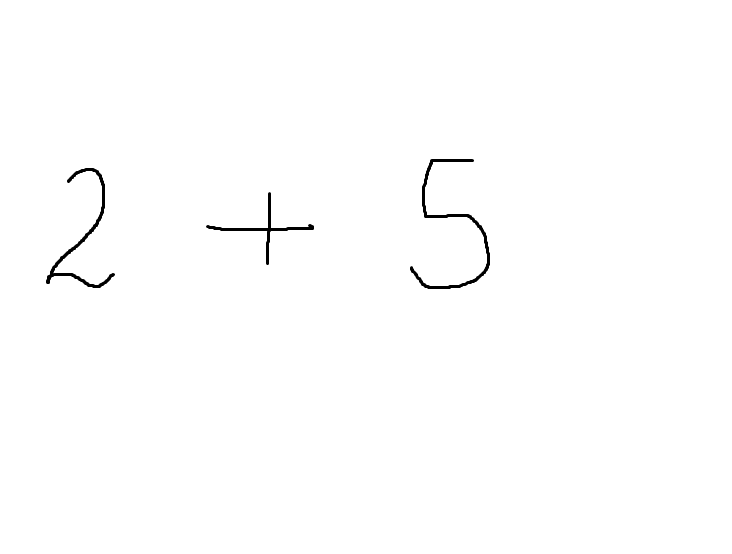

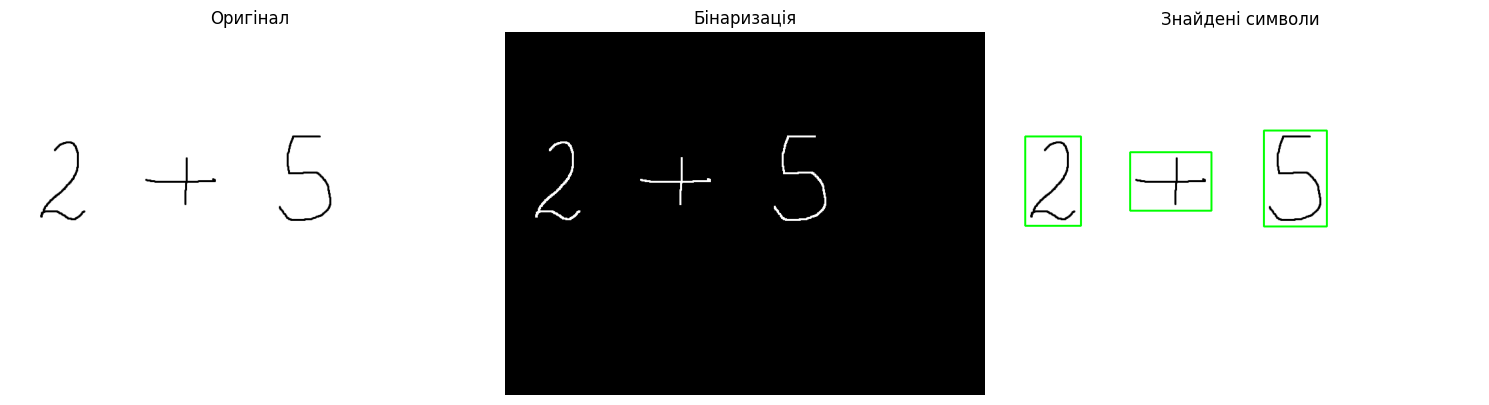

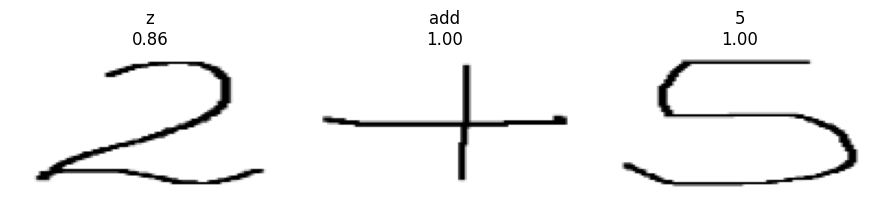

Розпізнаний вираз: zadd5
Класи: ['z', 'add', '5']


In [26]:
image_path = "/content/ВиразТест1.png"

expression, labels, confidences, boxes = predict_expression(
    image_path=image_path,
    model=model,
    class_names=class_names,
    img_size=IMG_SIZE,
    min_area=80,
    show_symbols=True
)

print("Розпізнаний вираз:", expression)
print("Класи:", labels)

In [27]:
from google.colab import files
uploaded = files.upload()

Saving ВиразТест2.png to ВиразТест2.png


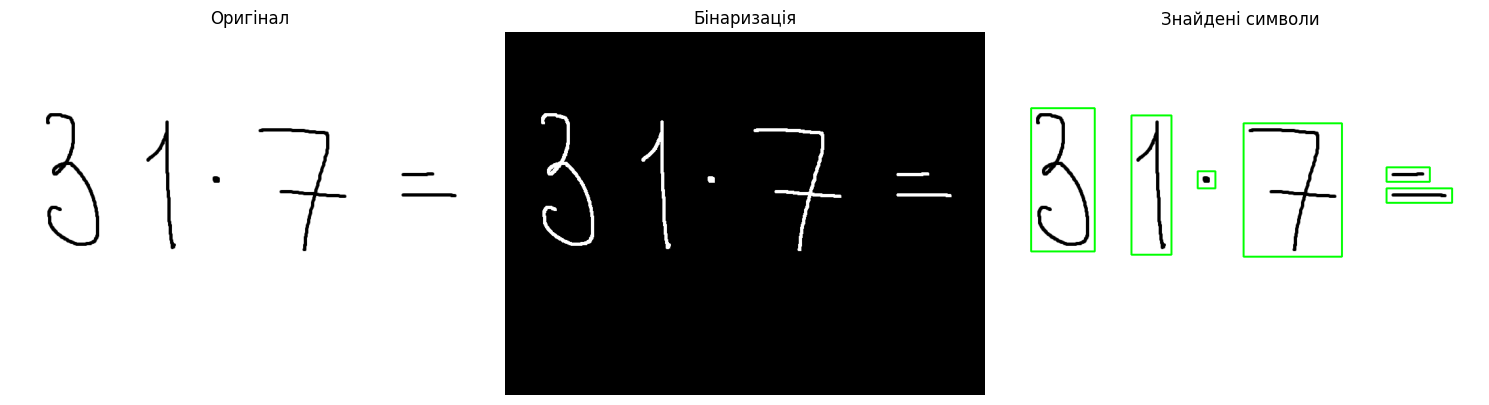

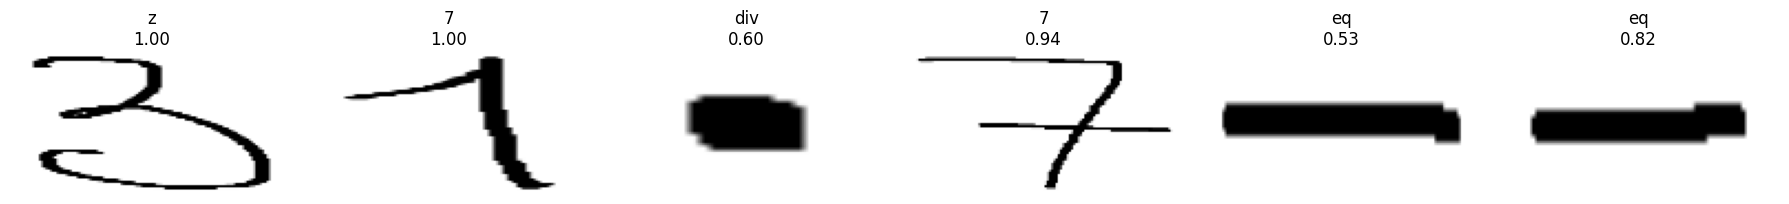

Розпізнаний вираз: z7div7eqeq
Класи: ['z', '7', 'div', '7', 'eq', 'eq']


In [28]:
image_path = "/content/ВиразТест2.png"

expression, labels, confidences, boxes = predict_expression(
    image_path=image_path,
    model=model,
    class_names=class_names,
    img_size=IMG_SIZE,
    min_area=80,
    show_symbols=True
)

print("Розпізнаний вираз:", expression)
print("Класи:", labels)